
===== DATA PREVIEW =====
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905     

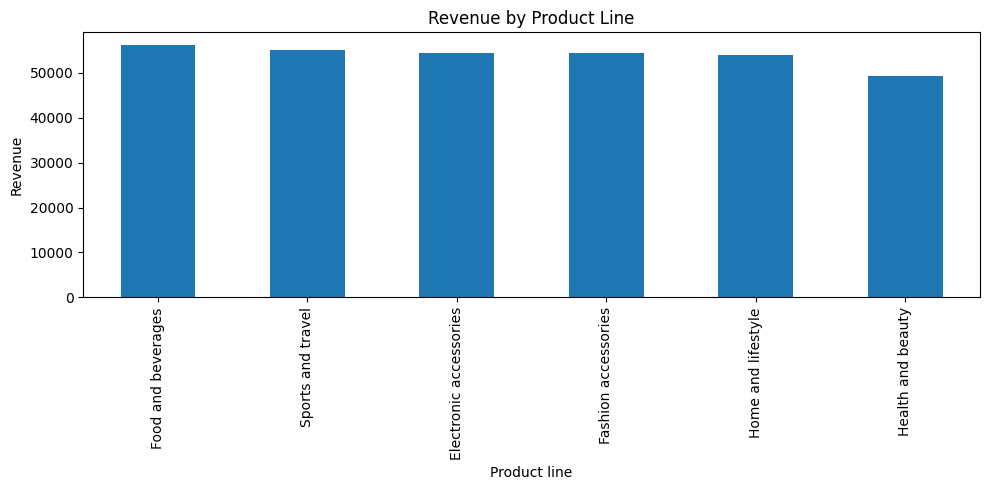

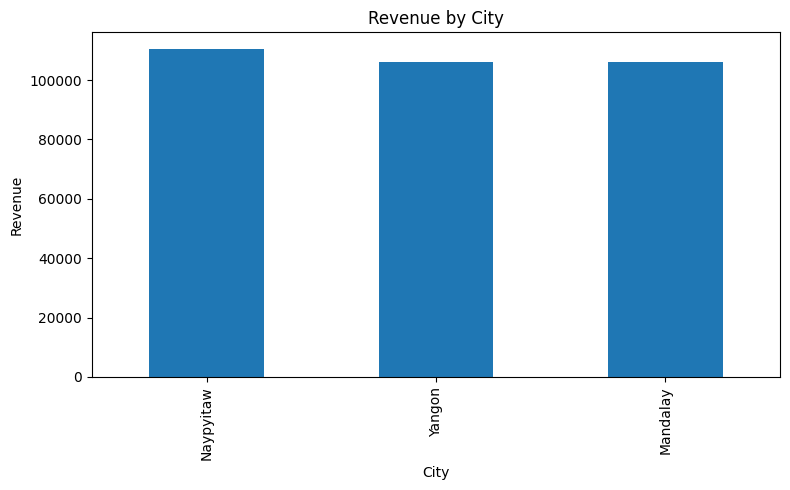

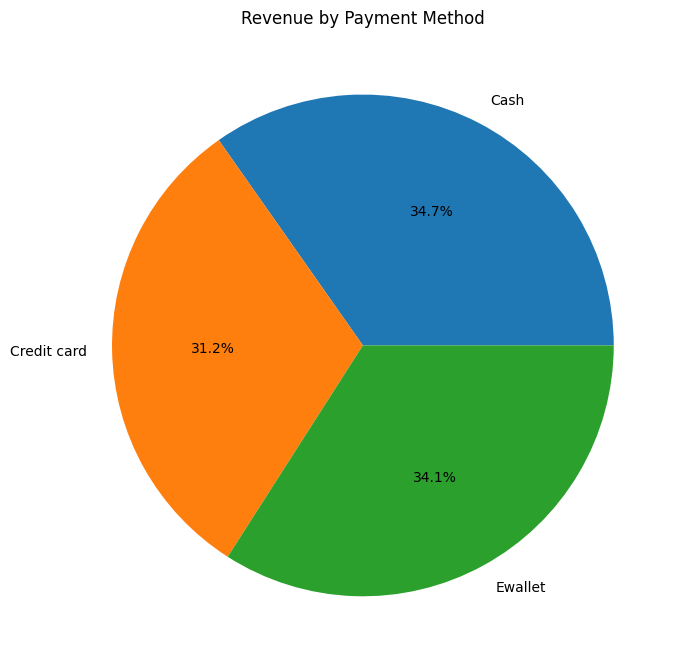

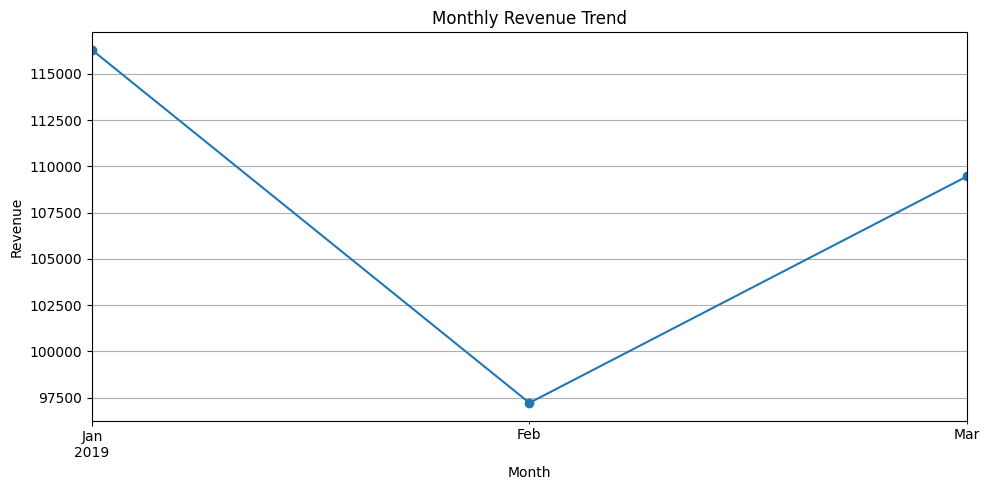

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("supermarket_sales - Sheet1.csv")

# Display first 5 rows
print("\n===== DATA PREVIEW =====")
print(df.head())

# Basic Analytics
total_revenue = df["Total"].sum()
average_rating = df["Rating"].mean()
total_transactions = len(df)

print("\n===== BUSINESS INSIGHTS =====")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions}")
print(f"Average Rating: {average_rating:.2f}")

# Top Product Lines
product_sales = (
    df.groupby("Product line")["Total"]
    .sum()
    .sort_values(ascending=False)
)

print("\n===== TOP PRODUCT LINES =====")
print(product_sales)

# Revenue by City
city_sales = (
    df.groupby("City")["Total"]
    .sum()
    .sort_values(ascending=False)
)

print("\n===== REVENUE BY CITY =====")
print(city_sales)

# Revenue by Payment Method
payment_sales = (
    df.groupby("Payment")["Total"]
    .sum()
)

print("\n===== PAYMENT METHOD REVENUE =====")
print(payment_sales)

# -----------------------------
# DASHBOARD CHARTS
# -----------------------------

# Chart 1: Revenue by Product Line
plt.figure(figsize=(10, 5))
product_sales.plot(kind="bar")
plt.title("Revenue by Product Line")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Chart 2: Revenue by City
plt.figure(figsize=(8, 5))
city_sales.plot(kind="bar")
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Chart 3: Payment Method Distribution
plt.figure(figsize=(7, 7))
payment_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue by Payment Method")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Chart 4: Monthly Revenue Trend
df["Date"] = pd.to_datetime(df["Date"])

monthly_revenue = (
    df.groupby(df["Date"].dt.to_period("M"))["Total"]
    .sum()
)

plt.figure(figsize=(10, 5))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.grid(True)
plt.tight_layout()
plt.show()